In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../jhani_pandit_dataset/Fitness_Survey__Responses_clean.xlsx')

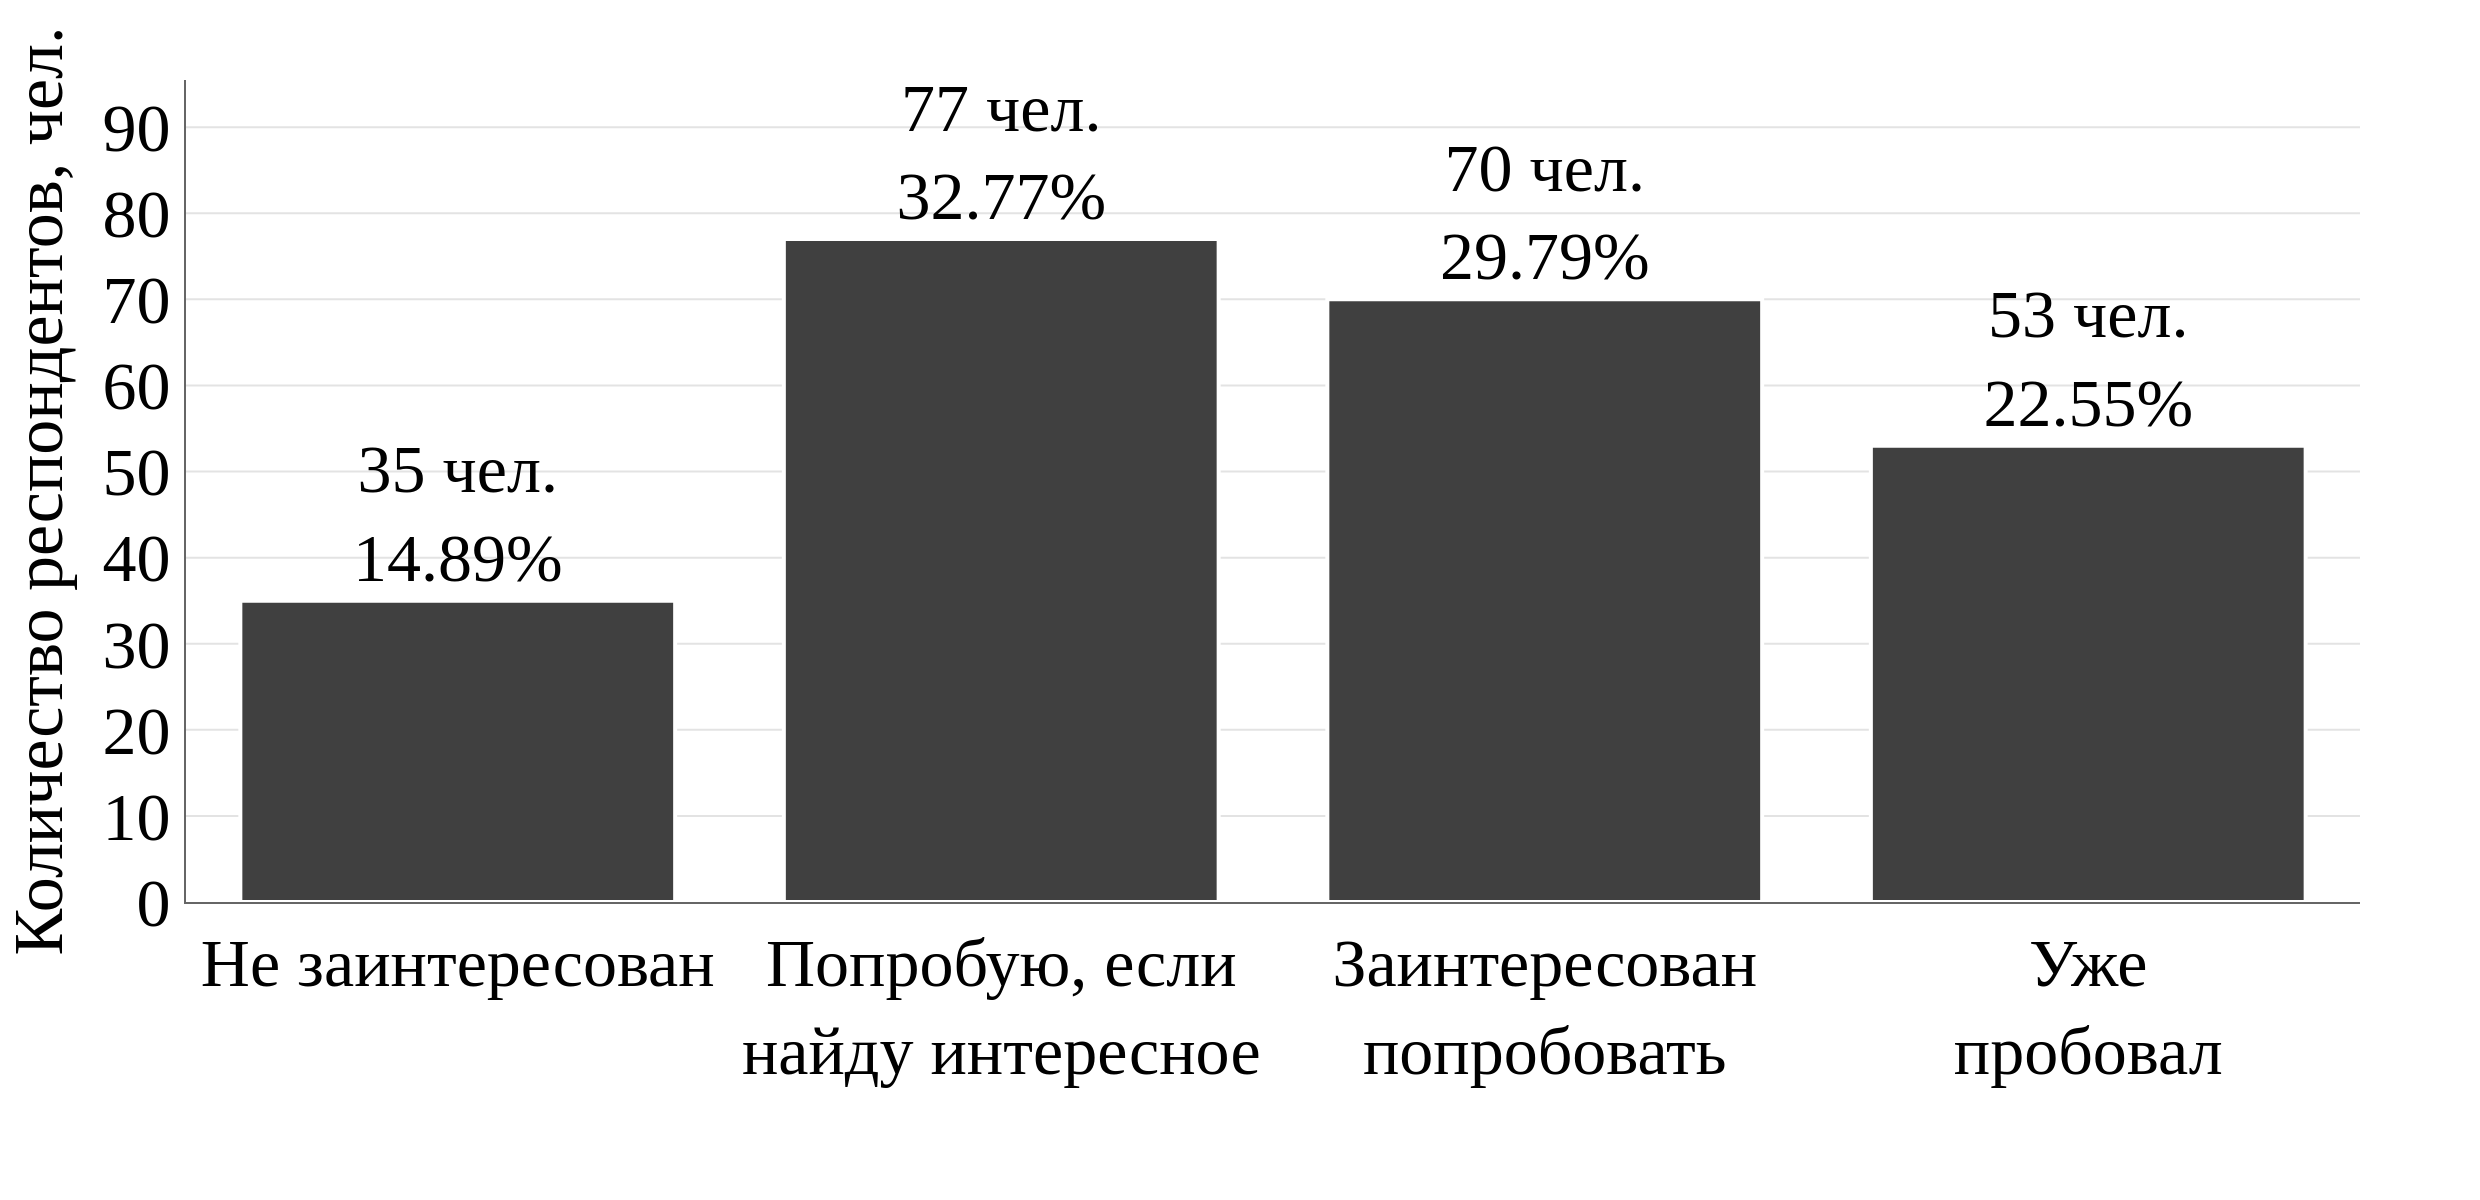

In [2]:
online_interest_col = (
    "How likely would you be to try a remote/online mode of training "
    "for your wellness/fitness routine?"
)

online_interest = df[online_interest_col].dropna().value_counts()

interest_order = [
    "I am not interested to try",
    "I may try only if I find something very interesting",
    "I am interested to try out",
    "I have already tried"
]

online_interest = online_interest.reindex(
    [x for x in interest_order if x in online_interest.index]
)

online_percent = (online_interest / online_interest.sum() * 100).round(2)

interest_ru = {
    "I am not interested to try": "Не заинтересован",
    "I may try only if I find something very interesting": "Попробую, если<br>найду интересное",
    "I am interested to try out": "Заинтересован<br>попробовать",
    "I have already tried": "Уже<br>пробовал"
}

labels = [interest_ru[x] for x in online_interest.index]

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=online_interest.values,
    orientation='v',
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(online_interest.values, online_percent)
    ],
    textposition='outside',
    textfont=dict(
        size=34,
        color='#000000',
        family='Times New Roman'
    ),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(
        family='Times New Roman',
        size=34,
        color='#000000'
    ),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=34),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=35),
        tickfont=dict(size=34),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, online_interest.max() * 1.24]
    ),
    margin=dict(
        l=60,
        r=60,
        t=40,
        b=120
    ),
    width=1240,
    height=600
)

fig.show()

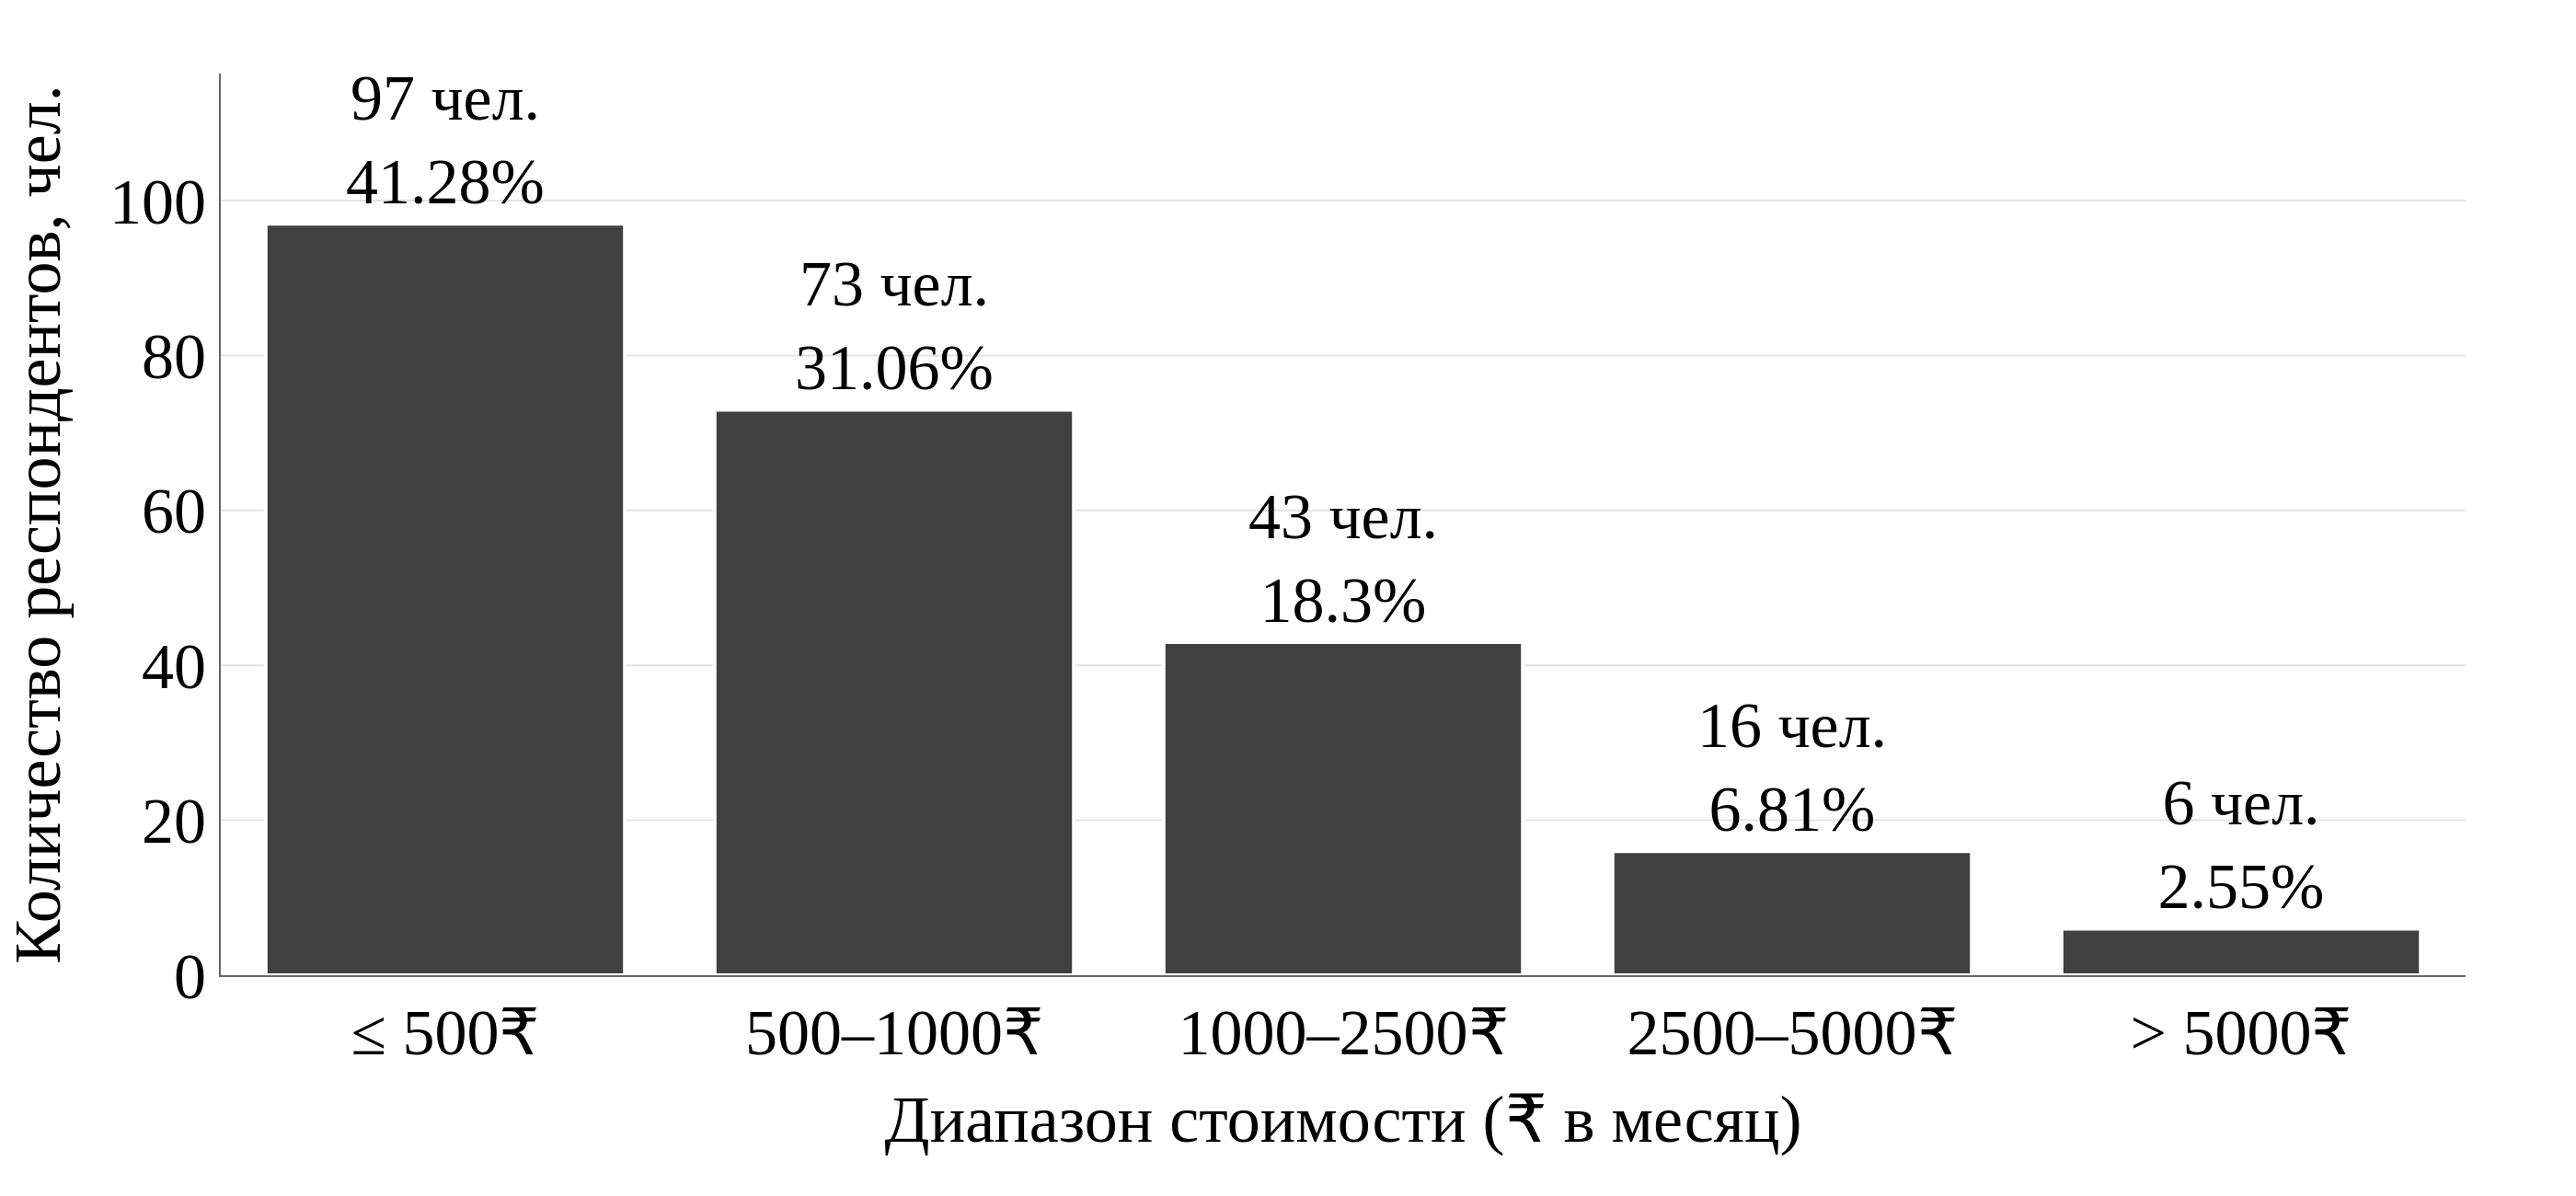

In [3]:
price_col = "How much would you be willing to pay for such an online wellness/fitness training service (INR/month)?"
price_data = df[price_col].dropna()

price_order = [
    "Not more than Rs. 500",
    "Rs. 500 - 1000",
    "Rs. 1000-2500",
    "Rs. 2500-5000",
    "More than Rs. 5000"
]

price_counts = price_data.value_counts().reindex(
    [p for p in price_order if p in price_data.values],
    fill_value=0
)

price_percent = (price_counts / price_counts.sum() * 100).round(2)

price_ru = {
    "Not more than Rs. 500": "≤ 500₹",
    "Rs. 500 - 1000": "500–1000₹",
    "Rs. 1000-2500": "1000–2500₹",
    "Rs. 2500-5000": "2500–5000₹",
    "More than Rs. 5000": "> 5000₹"
}

labels = [price_ru.get(x, x) for x in price_counts.index]

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=price_counts.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(price_counts.values, price_percent.values)
    ],
    textposition='outside',
    textfont=dict(
        size=35,
        color='#000000',
        family='Times New Roman'
    ),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(
        family='Times New Roman',
        size=35,
        color='#000000'
    ),
    xaxis=dict(
        title='Диапазон стоимости (₹ в месяц)',
        titlefont=dict(size=36),
        showgrid=False,
        tickfont=dict(size=35),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=36),
        tickfont=dict(size=35),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, price_counts.max() * 1.2]
    ),
    margin=dict(
        l=120,
        r=60,
        t=40,
        b=120
    ),
    height=650,
    width=1400
)

fig.show()

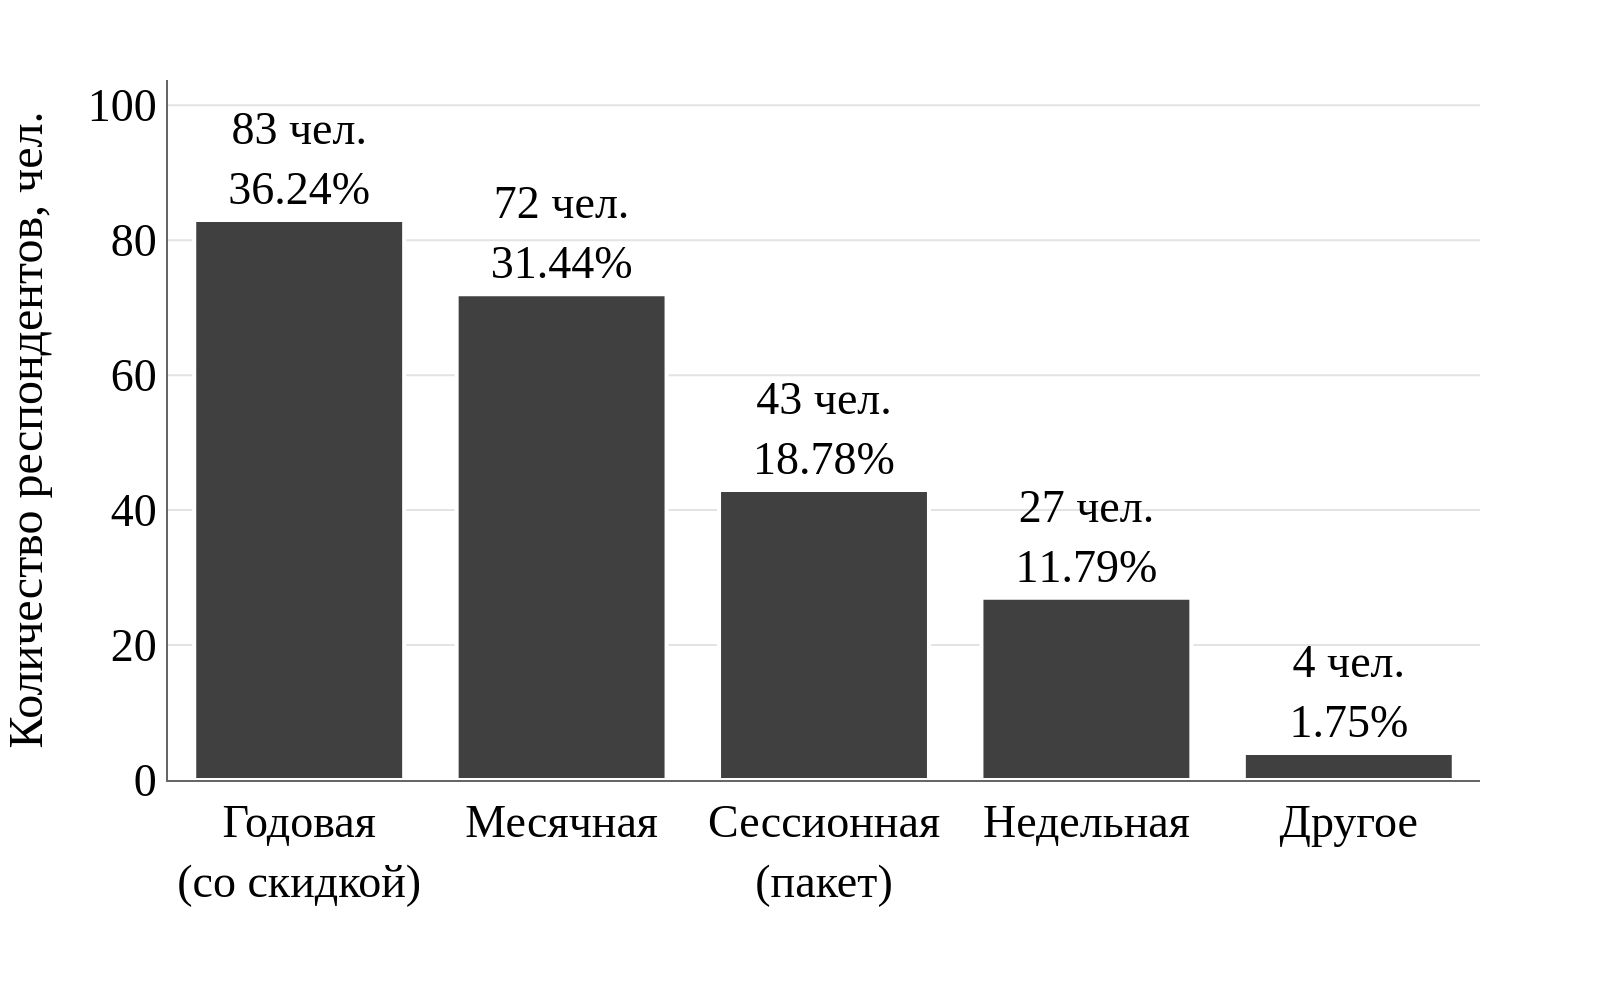

In [4]:
subscription_data = df["Subscription_cycle"].dropna().value_counts()
subscription_percent = (subscription_data / subscription_data.sum() * 100).round(2)

subscription_ru = {
    "Annual subscription": "Годовая<br>(со скидкой)",
    "Monthly subscription": "Месячная",
    "Weekly subscription": "Недельная",
    "Session-based subscription": "Сессионная<br>(пакет)",
    "Other": "Другое"
}

labels = [subscription_ru.get(x, x) for x in subscription_data.index]
values = subscription_data.values
percents = subscription_percent.values

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=values,
    orientation='v',
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(values, percents)
    ],
    textposition='outside',
    textfont=dict(
        size=23,
        color='#000000',
        family='Times New Roman'
    ),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(
        family='Times New Roman',
        size=23,
        color='#000000'
    ),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=24),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, max(values) * 1.25]
    ),
    margin=dict(
        l=60,
        r=60,
        t=40,
        b=100
    ),
    width=800
)

fig.show()